In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
df=pd.read_csv('compressed_data.csv',low_memory=False)

In [12]:
df.head(5)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [13]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [15]:
MISSING VALUES

SyntaxError: invalid syntax (1843082877.py, line 1)

In [16]:
df.isna().sum()         # CHECKING FOR NULL VALUES

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [17]:
df.isna().sum()/len(df) * 100

id                                 0.000000
NAME                               0.243667
host id                            0.000000
host_identity_verified             0.281679
host name                          0.395715
neighbourhood group                0.028265
neighbourhood                      0.015595
lat                                0.007797
long                               0.007797
country                            0.518524
country code                       0.127682
instant_bookable                   0.102340
cancellation_policy                0.074075
room type                          0.000000
Construction year                  0.208579
price                              0.240743
service fee                        0.266084
minimum nights                     0.398639
number of reviews                  0.178364
last review                       15.490404
reviews per month                 15.476759
review rate number                 0.317742
calculated host listings count  

In [18]:
df['id'].value_counts().head(10)    #CHECKING FOR REPEATED ID

id
20305326    2
20305878    2
20306430    2
20306983    2
20307535    2
20308087    2
20308639    2
20309192    2
20309744    2
20310296    2
Name: count, dtype: int64

In [19]:
df[df['id']==20305326]  # 20305326 ID IS TWICE ENTERED SO WE NEED TO DROP THE DUPLICATE ONE

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
34952,20305326,Studio Apartment in historic Sugar Hill townhouse,76800663749,unconfirmed,Paula,Manhattan,Harlem,40.82862,-73.93832,United States,...,$200,2.0,23.0,7/1/2019,2.24,3.0,2.0,16.0,-We do not allow pets because we already have ...,NaN
102282,20305326,Studio Apartment in historic Sugar Hill townhouse,76800663749,unconfirmed,Paula,Manhattan,Harlem,40.82862,-73.93832,United States,...,$200,2.0,23.0,7/1/2019,2.24,3.0,2.0,16.0,-We do not allow pets because we already have ...,NaN


HANDLING MISSING VALUES

In [20]:
df['last review']=pd.to_datetime(df['last review'] , errors='coerce')    # errors=coerce this function assigns blank/null ones as NAN
df['last review'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 102599 entries, 0 to 102598
Series name: last review
Non-Null Count  Dtype         
--------------  -----         
86706 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 801.7 KB


In [21]:
df['last review'].fillna(df['last review'].min() )  #fill the missing(nan) with the min of Last_review

0        2021-10-19
1        2022-05-21
2        2012-07-11
3        2019-07-05
4        2018-11-19
            ...    
102594   2012-07-11
102595   2015-07-06
102596   2012-07-11
102597   2015-10-11
102598   2012-07-11
Name: last review, Length: 102599, dtype: datetime64[ns]

In [22]:
df['last review']

0        2021-10-19
1        2022-05-21
2               NaT
3        2019-07-05
4        2018-11-19
            ...    
102594          NaT
102595   2015-07-06
102596          NaT
102597   2015-10-11
102598          NaT
Name: last review, Length: 102599, dtype: datetime64[ns]

In [23]:
df['last review'].isnull().sum()

np.int64(15893)

In [24]:
df['reviews per month']=df['reviews per month'].fillna(0)   #filling 0 into the nan cuz nan in this review column means there are no reviews come from the clients so its better to put 0 into it 

In [25]:
df['reviews per month'].isnull().sum()

np.int64(0)

In [26]:
#now there are null values in name and host name so drop them
df.dropna(subset =['NAME' ,'host name'], inplace=True)

In [27]:
df.isnull().sum()

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                        15777
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

In [28]:
df['host_identity_verified'].value_counts().head(10)

host_identity_verified
unconfirmed    50889
verified       50784
Name: count, dtype: int64

In [29]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaT,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,$115,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0,"No smoking, please, and no drugs.",NaN


In [30]:
#remove dollar sign and convert into float data tyo
df['service fee'] = df['service fee'].replace( '[$,]' ,'' ,regex=True).astype(float)
df['price']=df['price'].replace( '[$,]' , '',regex=True).astype(float)

In [31]:
df['service fee'].head()


0    193.0
1     28.0
2    124.0
4     41.0
5    115.0
Name: service fee, dtype: float64

In [32]:
df['price'].head()

0    966.0
1    142.0
2    620.0
4    204.0
5    577.0
Name: price, dtype: float64

REMOVE DUPLICATES

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

In [35]:
df.shape

(101410, 26)

DESSCRIPTIVE STATISTIC

In [36]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.014100e+05,1.014100e+05,101402.000000,101402.000000,101210.000000,101171.000000,101142.000000,101016.000000,101228.000000,85693,101410.000000,101103.000000,101092.000000,100990.000000
mean,2.920959e+07,4.926155e+10,40.728082,-73.949663,2012.486908,625.381008,125.043998,8.113744,27.511854,2019-06-11 10:55:18.740154112,1.163207,3.278558,7.948463,141.164660
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.507574e+07,2.459183e+10,40.688730,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2018-10-28 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.922911e+07,4.912069e+10,40.722300,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-06-14 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.328308e+07,7.399747e+10,40.762750,-73.932340,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-05 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.626820e+07,2.853703e+10,0.055850,0.049474,5.765130,331.609111,66.313374,30.378014,49.549258,NaN,1.683708,1.285369,32.328974,135.419199


VISUALIZATION

Text(0.5, 1.0, 'Distribution of listing price')

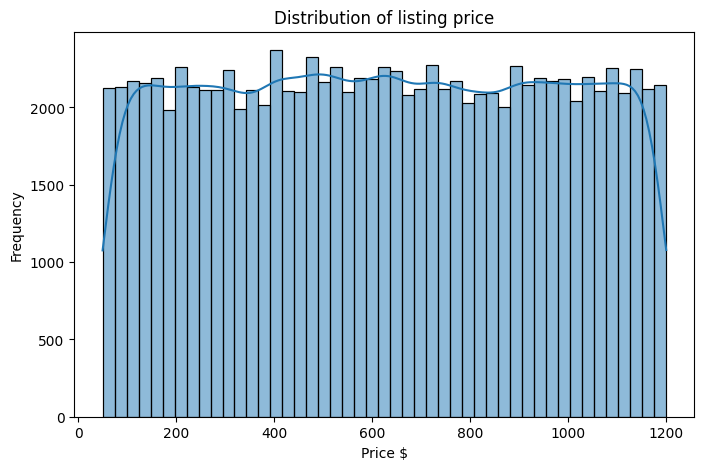

In [37]:
#what is the distribution of listing prices

plt.figure(figsize=(8,5))
sns.histplot(data=df['price'] , kde=True)   #kde shows the blue line..it shows how pricing is distributed
plt.xlabel('Price $')
plt.ylabel('Frequency')
plt.title('Distribution of listing price')

In [38]:
#histogram show a fairly ploting even distribution listing prices across various ranges.
#the KDE line helps visualize the even distribution more clearly 

In [39]:
df['room type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room', 'Hotel room'],
      dtype=object)

Text(0.5, 1.0, 'Room type distribution')

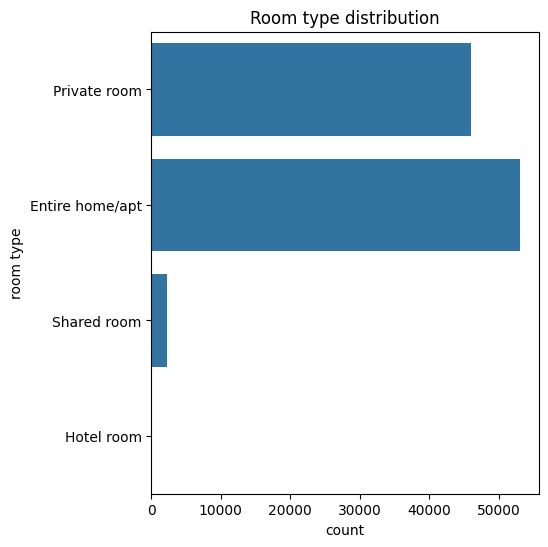

In [40]:
plt.figure(figsize=(5,6))
sns.countplot( data=df['room type'])
plt.title('Room type distribution')


<Axes: xlabel='room type', ylabel='count'>

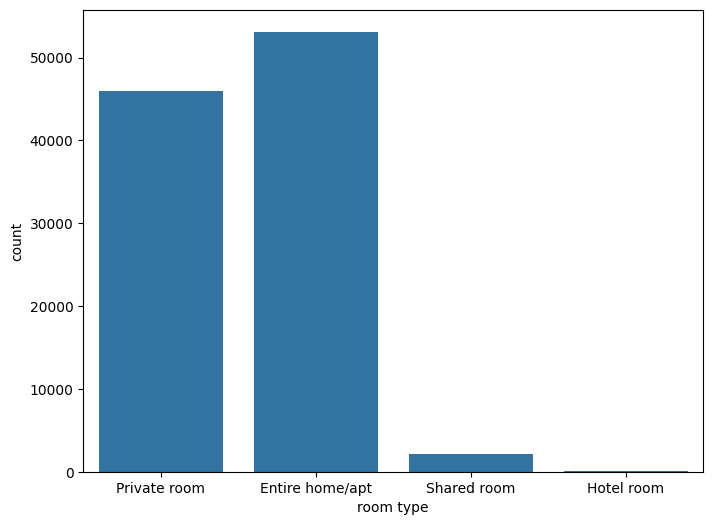

In [41]:
plt.figure(figsize=(8,6))
sns.countplot( x='room type' , data=df)

<Axes: xlabel='room type', ylabel='count'>

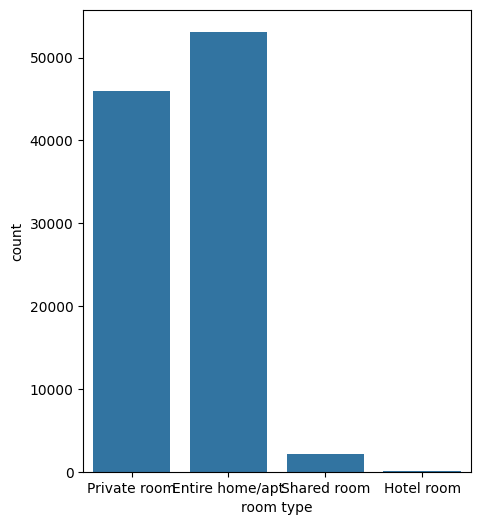

In [42]:
plt.figure(figsize=(5,6))
sns.countplot( x=df['room type'] , data=df)

In [43]:
#how arw listing distrubeted across differentt neighbourhood
df['neighbourhood group'].unique()  

array(['Brooklyn', 'Manhattan', 'brookln', 'manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object)

<Axes: xlabel='neighbourhood group', ylabel='count'>

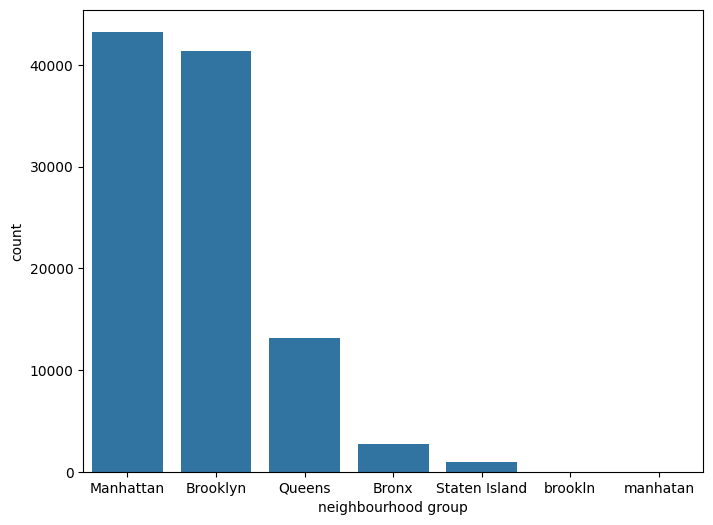

In [44]:
plt.figure(figsize=(8,6))
sns.countplot( x= df['neighbourhood group'] , data=df , order=df['neighbourhood group'].value_counts().index)

<Axes: xlabel='room type', ylabel='price'>

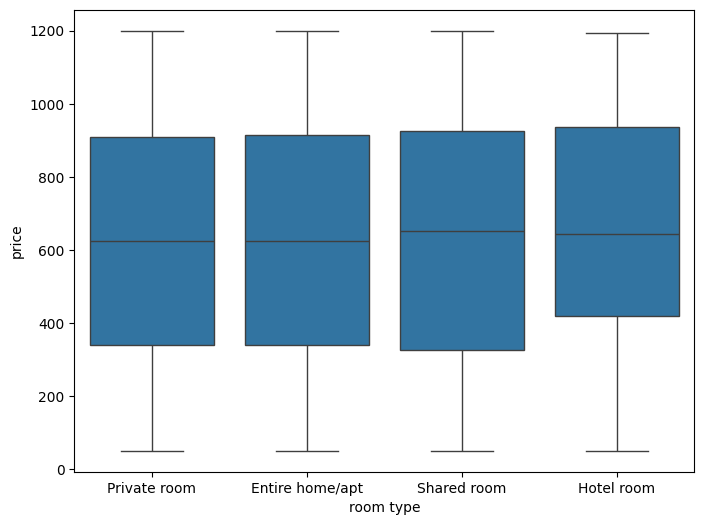

In [45]:
#what is the relationship between price and room type

plt.figure(figsize=(8,6))
sns.boxplot(  data=df ,x=df['room type'] , y=df['price'])   #boxplot shows range like for hotel room 

In [46]:
#how has the reviews changed over time
df['last review'].info()

<class 'pandas.core.series.Series'>
Index: 101410 entries, 0 to 102057
Series name: last review
Non-Null Count  Dtype         
--------------  -----         
85693 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 MB


In [47]:
reviews_over_time = (
    df.groupby(df['last review'].dt.to_period('M'))
      .size()
      .to_timestamp()
)

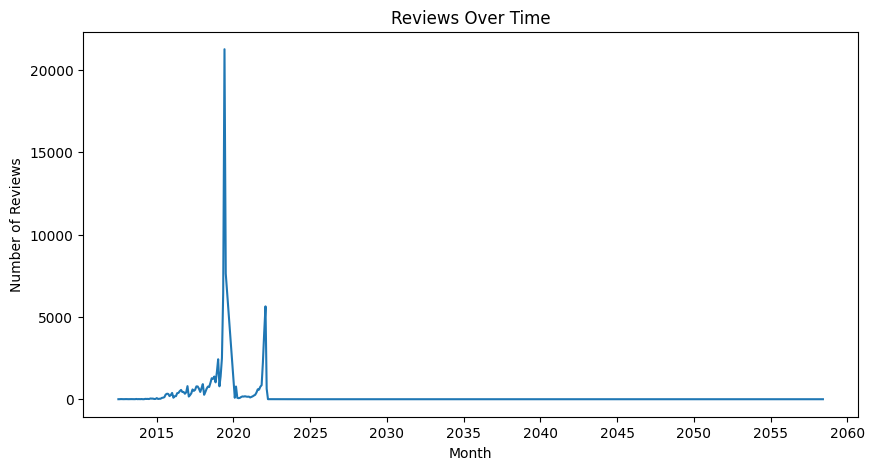

In [48]:
plt.figure(figsize=(10,5))
plt.plot(reviews_over_time)
plt.title('Reviews Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.show()

In [49]:
df['neighbourhood group'].unique()

array(['Brooklyn', 'Manhattan', 'brookln', 'manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object)

In [50]:
df['neighbourhood group'] = df['neighbourhood group'].str.upper()

df['neighbourhood group'] = df['neighbourhood group'].replace({'BROOKLN': 'BROOKLYN','MANHATAN': 'MANHATTAN'})

In [51]:
df['neighbourhood group'].unique()

array(['BROOKLYN', 'MANHATTAN', 'QUEENS', nan, 'STATEN ISLAND', 'BRONX'],
      dtype=object)

In [52]:
#which neighbourhood group has highest avg listing price
df.groupby('neighbourhood group')['price'].mean()


neighbourhood group
BRONX            627.634219
BROOKLYN         626.476692
MANHATTAN        622.822593
QUEENS           629.980824
STATEN ISLAND    623.314894
Name: price, dtype: float64

In [53]:
df['neighbourhood group'].value_counts().sort_values(ascending=True)

neighbourhood group
STATEN ISLAND      943
BRONX             2678
QUEENS           13120
BROOKLYN         41364
MANHATTAN        43279
Name: count, dtype: int64

In [54]:
#Therefore since MANHATAN has highest count of customers.it is because its pricing is low compared to others

In [55]:
df.groupby('room type')['price'].mean().sort_values(ascending=False)

room type
Hotel room         666.391304
Shared room        634.542505
Entire home/apt    625.380929
Private room       624.841233
Name: price, dtype: float64

In [56]:
df['room type'].value_counts()

room type
Entire home/apt    53132
Private room       45967
Shared room         2196
Hotel room           115
Name: count, dtype: int64

In [57]:
#There are less number of customers into hotel room cuz the pricing of hotel room is more compared to others

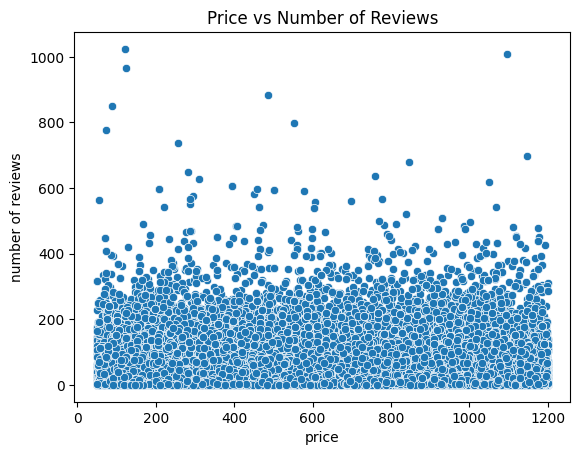

In [60]:
#Do more expensive listings get more reviews?
sns.scatterplot(data=df,
                x='price',
                y='number of reviews')
plt.title('Price vs Number of Reviews')
plt.show()

In [62]:
#Which hosts own the most properties?
top_hosts = df['host name'].value_counts().head(10)
print(top_hosts)

host name
Michael         877
David           759
John            576
Alex            541
Sonder (NYC)    515
Daniel          468
Karen           436
Sarah           428
Maria           420
Anna            396
Name: count, dtype: int64


In [71]:
#Which room type receives the most reviews?
df.groupby('room type') ['number of reviews'].mean().sort_values(ascending=False)

room type
Hotel room         84.078261
Private room       27.864890
Entire home/apt    27.378529
Shared room        20.398452
Name: number of reviews, dtype: float64

<Axes: xlabel='room type', ylabel='number of reviews'>

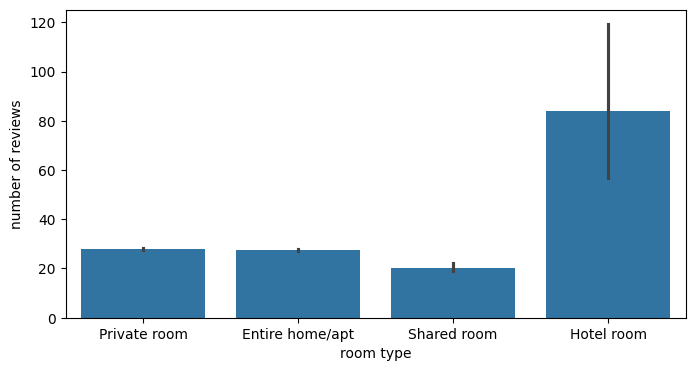

In [79]:
plt.figure(figsize=(8,4))
sns.barplot( x=('room type'), y=('number of reviews') , data=df)

In [72]:
#hotel rooms gets more reviews i.e 84 total reviews

<Axes: xlabel='neighbourhood group', ylabel='availability 365'>

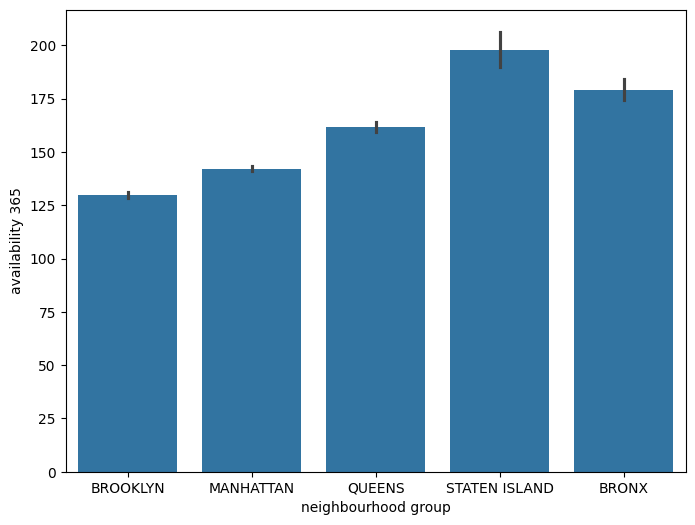

In [78]:
plt.figure(figsize=(8,6))
sns.barplot( data=df , x='neighbourhood group' , y='availability 365')

<Axes: xlabel='service fee', ylabel='price'>

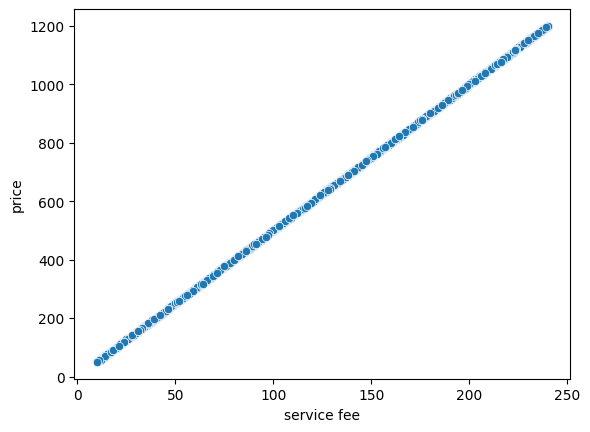

In [80]:
#What is the relationship between service fee and listing price?
sns.scatterplot(
    data=df,
    x='service fee',
    y='price'
)

In [84]:
#Which month has the highest review activity?
df['month']=df['last review'].dt.month_name()

In [86]:
df['last review'].info()

<class 'pandas.core.series.Series'>
Index: 101410 entries, 0 to 102057
Series name: last review
Non-Null Count  Dtype         
--------------  -----         
85693 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 MB


<Axes: xlabel='month', ylabel='count'>

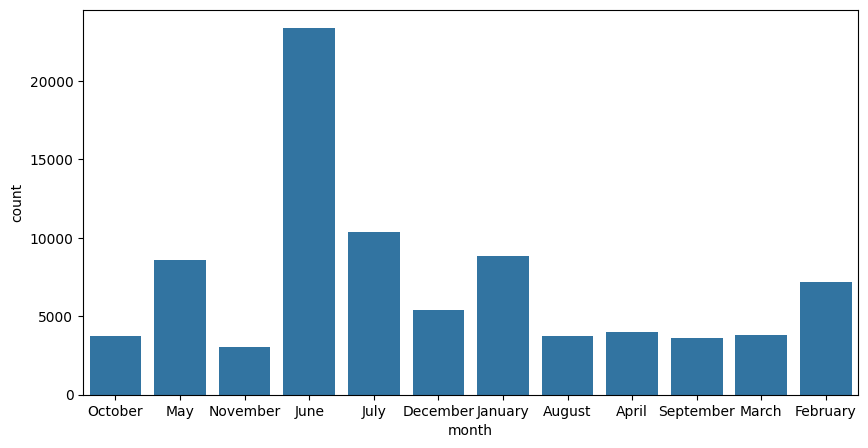

In [90]:
plt.figure(figsize=(10,5))
sns.countplot( x='month' ,data= df)

In [ ]:
# june month got more number of reviews